In [2]:
!pip install shap lime pandas numpy scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dd973857df963157beeaeac72a3ebffbba11143defe287a318e4d9b77cf647e8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

import shap
from lime.lime_tabular import LimeTabularExplainer

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Exploratory Data Analysis (EDA)

In [6]:
print("Rows, cols:", df.shape)
display(df.info())
display(df.describe(include='all').T)

Rows, cols: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [7]:
print("Missing values per column:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Duplicate rows: 0


In [8]:
target = 'Exited' if 'Exited' in df.columns else df.columns[-1]
print("Target column used:", target)

if df[target].nunique() <= 10:
    display(df[target].value_counts())
else:
    display(df[target].hist(bins=30))

Target column used: Exited


,count
Exited,
0,7963
1,2037


## Data cleaning



In [9]:
# Remove Irrelevant Columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [10]:
# Handle Invalid Data
print("\n=== Checking for Invalid Data ===")
print(f"Negative CreditScore: {(df_clean['CreditScore'] < 0).sum()}")
print(f"Negative Age: {(df_clean['Age'] < 18).sum()}")
print(f"Negative Balance: {(df_clean['Balance'] < 0).sum()}")


=== Checking for Invalid Data ===
Negative CreditScore: 0
Negative Age: 0
Negative Balance: 0


In [11]:
# Outlier Detection
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Check outliers in numeric columns
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
for col in numeric_cols:
    outliers = detect_outliers_iqr(df_clean, col)
    print(f"\n{col} outliers: {len(outliers)}")


CreditScore outliers: 15

Age outliers: 359

Tenure outliers: 0

Balance outliers: 0

EstimatedSalary outliers: 0


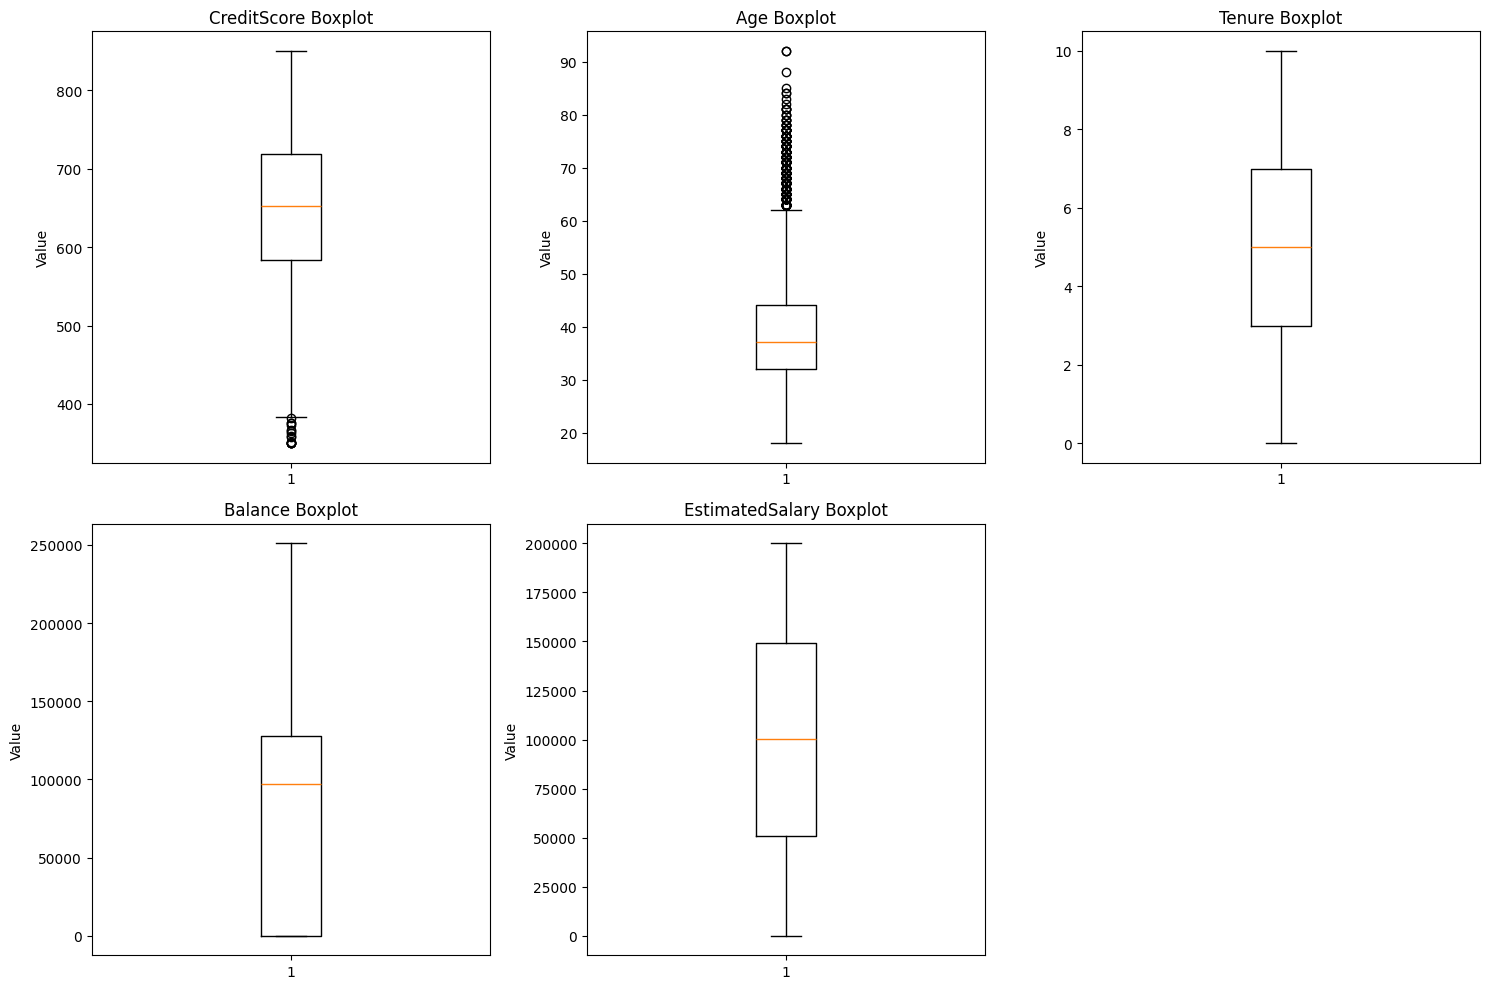

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df_clean[col].dropna())
    axes[idx].set_title(f'{col} Boxplot')
    axes[idx].set_ylabel('Value')

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [18]:
print (df_clean)

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0             619    France  Female   42       2       0.00              1   
1             608     Spain  Female   41       1   83807.86              1   
2             502    France  Female   42       8  159660.80              3   
3             699    France  Female   39       1       0.00              2   
4             850     Spain  Female   43       2  125510.82              1   
...           ...       ...     ...  ...     ...        ...            ...   
9995          771    France    Male   39       5       0.00              2   
9996          516    France    Male   35      10   57369.61              1   
9997          709    France  Female   36       7       0.00              1   
9998          772   Germany    Male   42       3   75075.31              2   
9999          792    France  Female   28       4  130142.79              1   

      HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0   

In [13]:
# To remove CreditScore outliers
#Calculate Q1, Q3, and IQR for CreditScore
Q1 = df_clean['CreditScore'].quantile(0.25)
Q3 = df_clean['CreditScore'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_clean[
    (df_clean['CreditScore'] >= lower) &
    (df_clean['CreditScore'] <= upper)
]

print("Shape after removing CreditScore outliers:", df_clean.shape)


Shape after removing CreditScore outliers: (9985, 11)


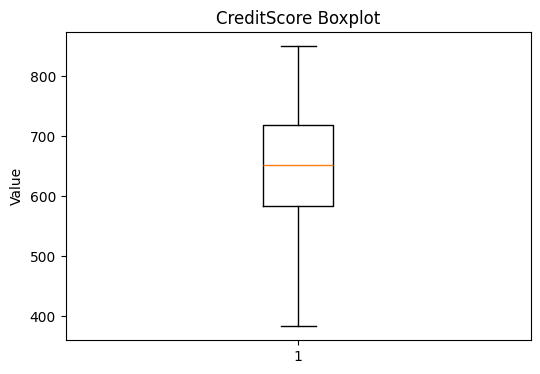

In [14]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean['CreditScore'].dropna())
plt.title('CreditScore Boxplot')
plt.ylabel('Value')
plt.show()

In [15]:
df = df_clean

## Visualization

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Categorical columns: ['Geography', 'Gender']


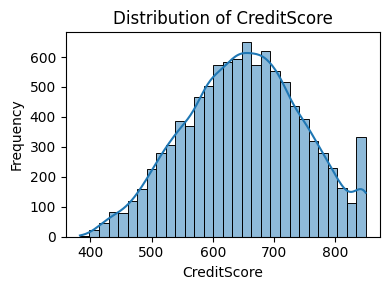

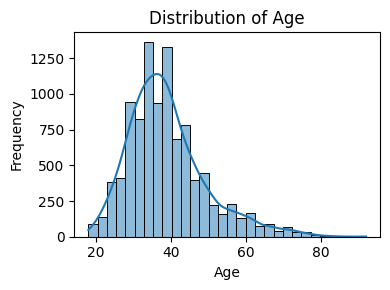

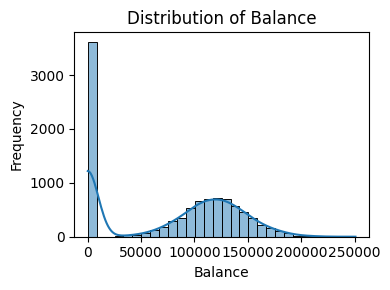

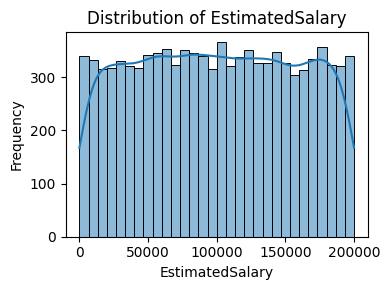

In [17]:
# Distribution of Numeric Features
selected_cols = ['CreditScore', 'Age', 'Balance','EstimatedSalary' ]

for col in selected_cols:
    plt.figure(figsize=(4,3))
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


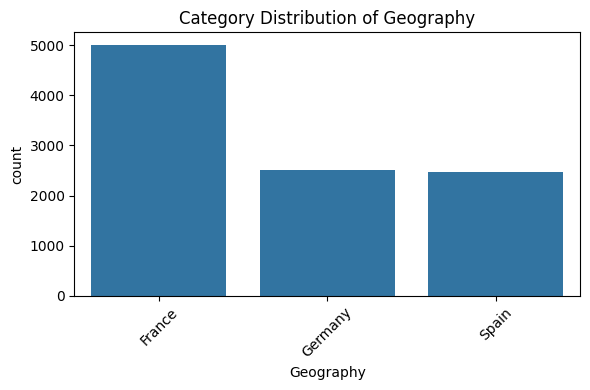

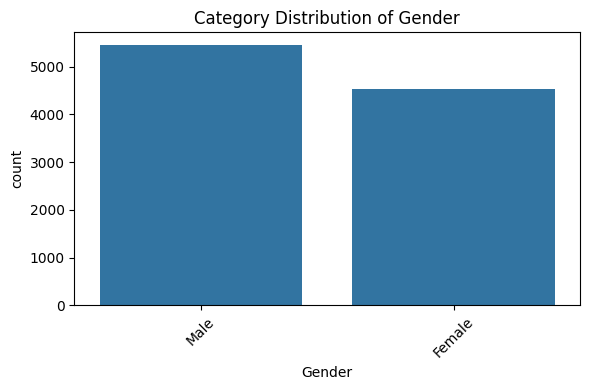

In [18]:
# Categorical Feature Distributions
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Category Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


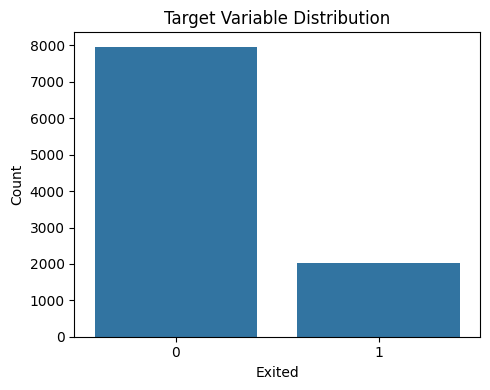

Exited
0    0.797496
1    0.202504
Name: proportion, dtype: float64


In [19]:
# Target Variable Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=df[target])
plt.title('Target Variable Distribution')
plt.xlabel(target)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df[target].value_counts(normalize=True))


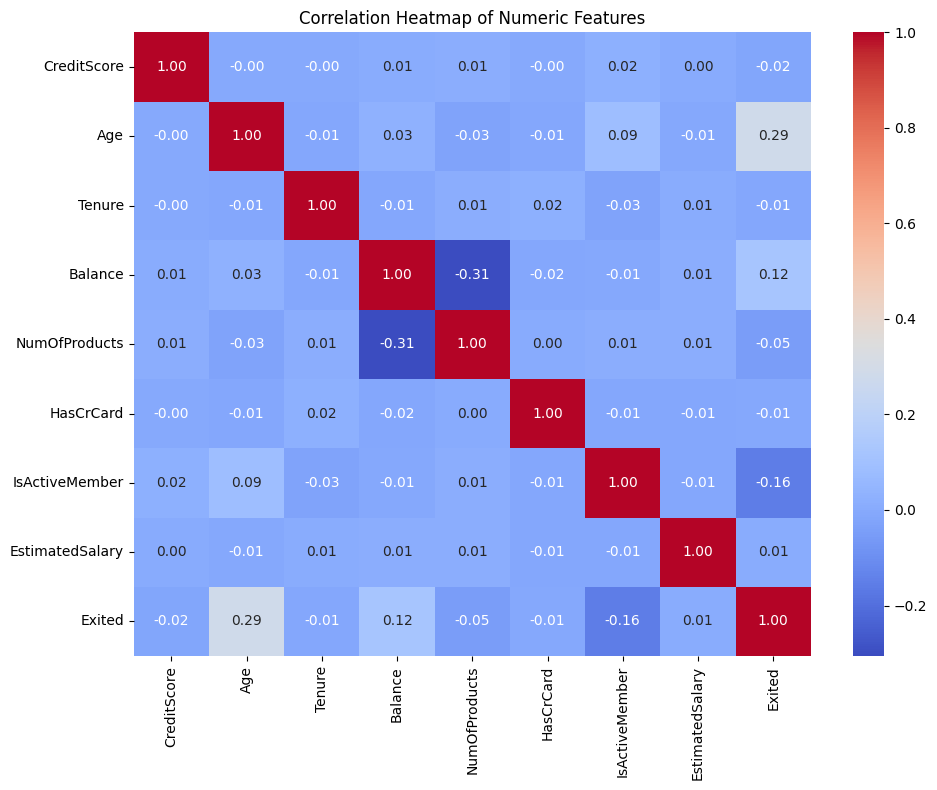

In [20]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


Selected features for pairplot: ['Age', 'IsActiveMember', 'Balance', 'NumOfProducts', 'CreditScore']


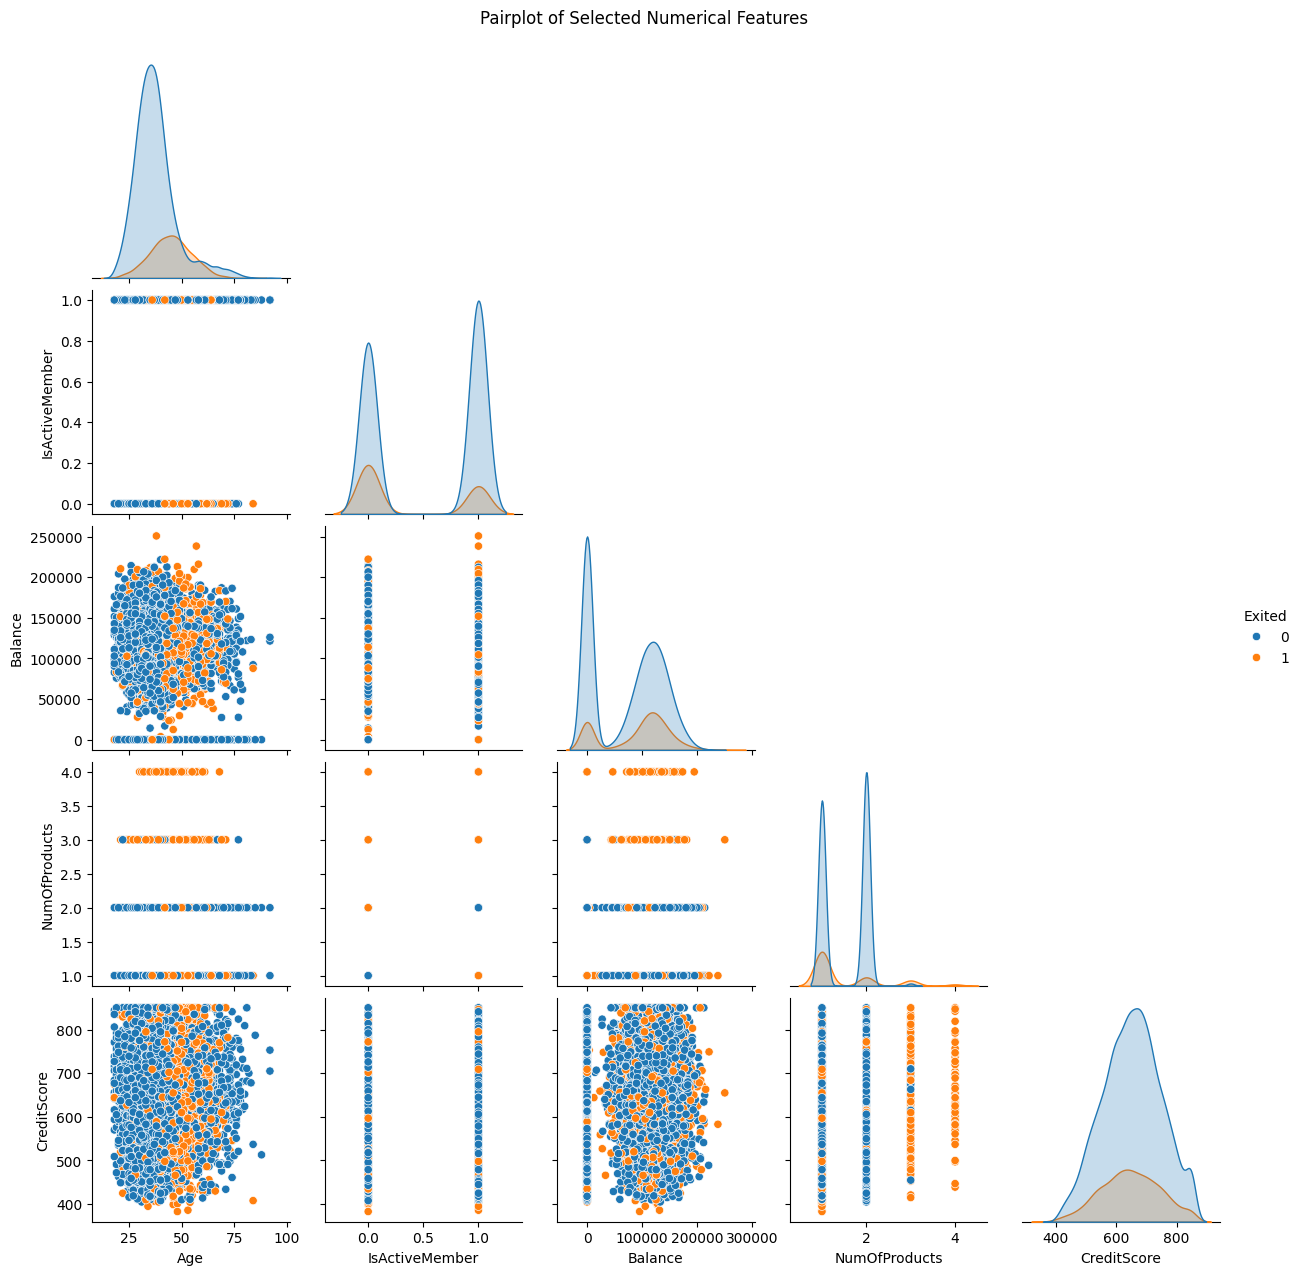

In [21]:
# Relationships Between Numerical Features(Pairplot)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from features list if included
numeric_cols.remove(target)

# Select top correlated features with target(max 5)
corr_with_target = df[numeric_cols + [target]].corr()[target].abs().sort_values(ascending=False)

top_numeric_features = corr_with_target.index[1:6].tolist()
print("Selected features for pairplot:", top_numeric_features)

# Create the Pairplot
sns.pairplot(
    df[top_numeric_features + [target]],
    hue=target if df[target].nunique() <= 5 else None,
    diag_kind='kde',
    corner=True
)
plt.suptitle("Pairplot of Selected Numerical Features", y=1.02)
plt.show()



In [30]:
target_corr = correlation_matrix['Exited'].sort_values(ascending=False)
print("\n=== Top Correlations with Churn ===")
print(target_corr)


=== Top Correlations with Churn ===
Exited                     1.000000
AgeGroup_Senior            0.338721
Age                        0.285134
Geo_Germany                0.174027
HasBalance                 0.122631
Balance                    0.118517
IsHighValue                0.065527
BalanceToSalaryRatio       0.026133
AgeGroup_Elderly           0.024907
EstimatedSalary            0.010171
TenureCategory_Moderate    0.007101
HasCrCard                 -0.008216
Tenure                    -0.013080
TenureCategory_Long       -0.015849
CreditScore               -0.018384
NumOfProducts             -0.048075
Geo_Spain                 -0.053462
Gender                    -0.106436
EngagementScore           -0.115025
AgeGroup_Middle           -0.137851
IsActiveMember            -0.155228
Name: Exited, dtype: float64


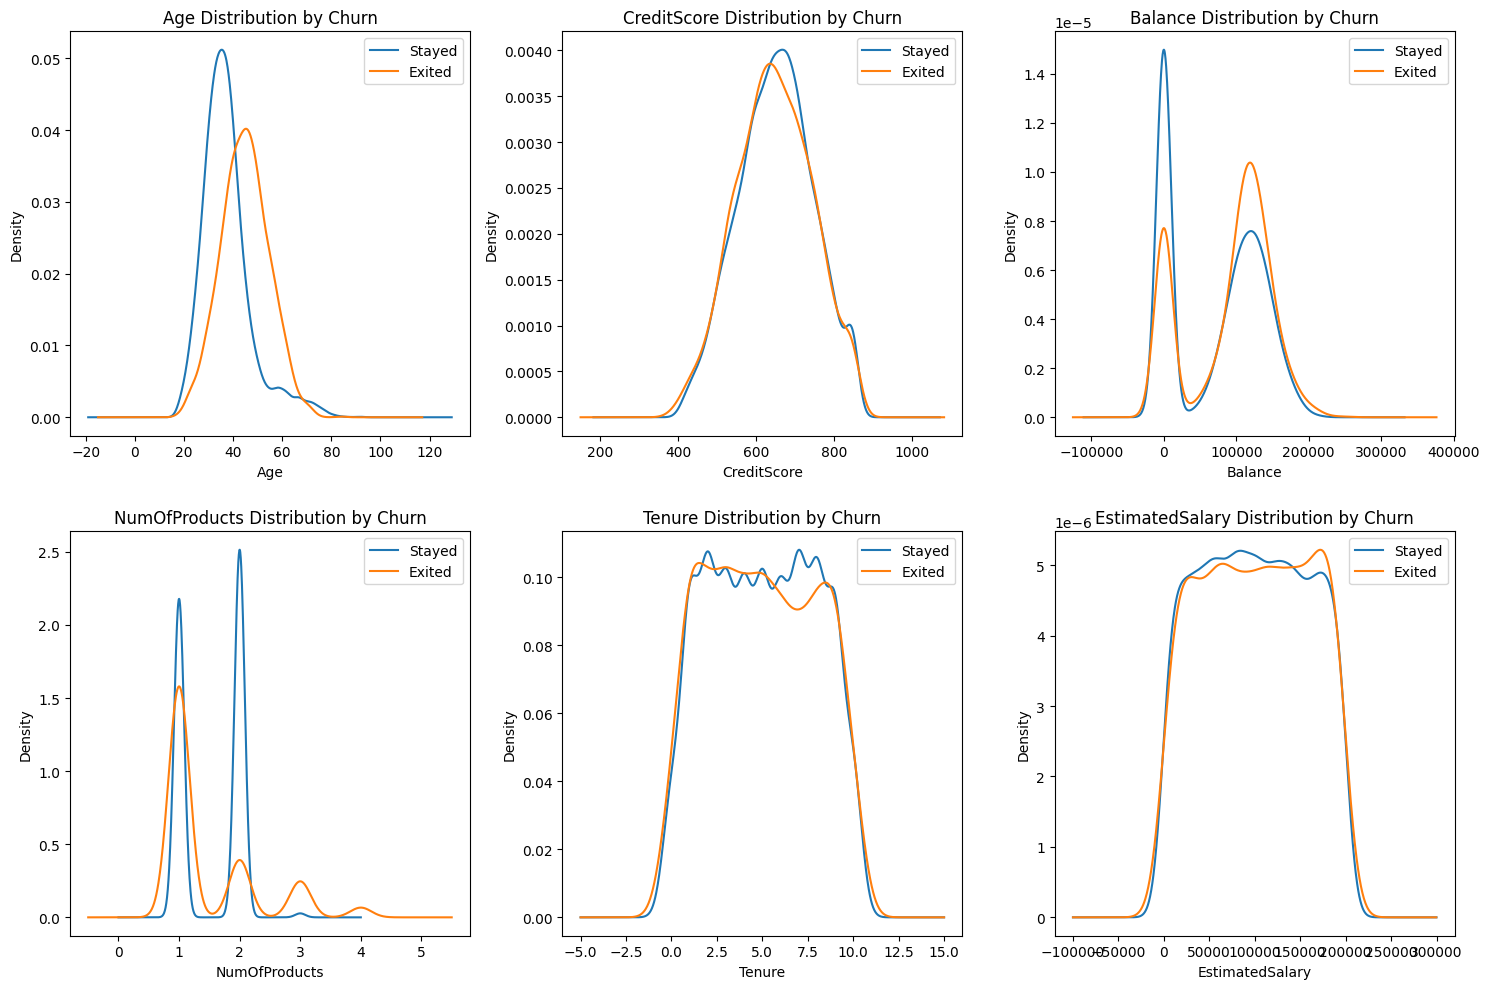

In [32]:
# Feature Distributions by Churn

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['Age', 'CreditScore', 'Balance', 'NumOfProducts', 'Tenure', 'EstimatedSalary']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    df_clean.groupby('Exited')[feature].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(f'{feature} Distribution by Churn')
    ax.set_xlabel(feature)
    ax.legend(['Stayed', 'Exited'])
plt.tight_layout()
plt.show()

## Feature Engineering & Transformation

In [22]:
df_engineered = df_clean.copy()

# Feature 1: Balance-to-Salary Ratio
df_engineered['BalanceToSalaryRatio'] = df_engineered['Balance'] / (df_engineered['EstimatedSalary'] + 1)

# Feature 2: Age Groups
df_engineered['AgeGroup'] = pd.cut(df_engineered['Age'],
                                    bins=[0, 30, 45, 60, 100],
                                    labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Feature 3: Balance Category
df_engineered['HasBalance'] = (df_engineered['Balance'] > 0).astype(int)

# Feature 4: Product Engagement Score
df_engineered['EngagementScore'] = (
    df_engineered['NumOfProducts'] * 0.4 +
    df_engineered['IsActiveMember'] * 0.3 +
    df_engineered['HasCrCard'] * 0.3
)

# Feature 5: Tenure Category
df_engineered['TenureCategory'] = pd.cut(df_engineered['Tenure'],
                                          bins=[-1, 2, 5, 10],
                                          labels=['New', 'Moderate', 'Long'])

# Feature 6: High-Value Customer (combination of balance and salary)
df_engineered['IsHighValue'] = (
    (df_engineered['Balance'] > df_engineered['Balance'].median()) &
    (df_engineered['EstimatedSalary'] > df_engineered['EstimatedSalary'].median())
).astype(int)

print("\n=== New Features Created ===")
print(df_engineered[['BalanceToSalaryRatio', 'HasBalance', 'EngagementScore', 'IsHighValue']].head())


=== New Features Created ===
   BalanceToSalaryRatio  HasBalance  EngagementScore  IsHighValue
0              0.000000           0              1.0            0
1              0.744670           1              0.7            0
2              1.401362           1              1.5            1
3              0.000000           0              0.8            0
4              1.587035           1              1.0            0


In [24]:
# Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

# One-hot encoding for Geography
df_encoded = pd.get_dummies(df_engineered, columns=['Geography'], prefix='Geo', drop_first=True)

# Label encoding for Gender (Binary)
le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])  # Female=0, Male=1

# Encode newly created categorical features
df_encoded = pd.get_dummies(df_encoded, columns=['AgeGroup', 'TenureCategory'], drop_first=True)

In [26]:
# Feature Scaling

# Separate features and target
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# Identify numeric columns for scaling
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                   'EstimatedSalary', 'BalanceToSalaryRatio', 'EngagementScore']

# Apply StandardScaler
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFeature Engineering Complete!")
print(f"Total Features: {X.shape[1]}")
print(f"\nFeature Names:\n{list(X.columns)}")


Feature Engineering Complete!
Total Features: 20

Feature Names:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalaryRatio', 'HasBalance', 'EngagementScore', 'IsHighValue', 'Geo_Germany', 'Geo_Spain', 'AgeGroup_Middle', 'AgeGroup_Senior', 'AgeGroup_Elderly', 'TenureCategory_Moderate', 'TenureCategory_Long']


## Model Development

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

Training Set: (7988, 20)
Test Set: (1997, 20)


In [37]:
# Logistic Regression(Linear Model)

print("MODEL 1: LOGISTIC REGRESSION")

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Training Complete!")

MODEL 1: LOGISTIC REGRESSION
Logistic Regression Training Complete!


In [38]:
# Ridge Regression(L2 Regularization)

print("MODEL 2: RIDGE REGRESSION")

# Ridge with LogisticRegression (penalty='l2')
ridge_reg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
ridge_reg.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_reg.predict(X_test)
y_prob_ridge = ridge_reg.predict_proba(X_test)[:, 1]

print("Ridge Regression Training Complete!")

MODEL 2: RIDGE REGRESSION
Ridge Regression Training Complete!


In [47]:
# Lasso Regression(L1 Regularization)

print("MODEL 3: LASSO REGRESSION")

# Lasso with LogisticRegression (penalty='l1')
lasso_reg = LogisticRegression(penalty='l1', C=1.0, max_iter=1000, random_state=42, solver='saga')
lasso_reg.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_reg.predict(X_test)
y_prob_lasso = lasso_reg.predict_proba(X_test)[:, 1]

print("Lasso Regression Training Complete!")

MODEL 3: LASSO REGRESSION
Lasso Regression Training Complete!


In [50]:
print("MODEL 4: DECISION TREE")

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Training Complete!")

MODEL 4: DECISION TREE
Decision Tree Training Complete!


##  Model Evaluation & Comparison

In [59]:
#Evaluation Metrics Function

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model_custom(clf, X_train, X_test, y_train, y_test, y_prob, model_name):
    print(f"\n{model_name} - EVALUATION METRICS")
    print("-" * 45)

    # For regression metrics
    mse = mean_squared_error(y_test, y_prob)
    r2_test = r2_score(y_test, y_prob)
    r2_train = r2_score(y_train, clf.predict_proba(X_train)[:, 1])
    variance_accuracy = 1 - (mse / y_test.var())

    print(f"MSE (Test): {mse:.4f}")
    print(f"R² (Train): {r2_train:.4f}")
    print(f"R² (Test): {r2_test:.4f}")
    print(f"Variance Accuracy: {variance_accuracy:.4f}")

    # For classification metrics
    y_pred = (y_prob >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    return {
        'Model': model_name,
        'MSE': mse,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Variance_Accuracy': variance_accuracy,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc
    }



In [60]:
#Evaluate All Models

results = []

# Logistic Regression
results.append(
    evaluate_model_custom(
        log_reg, X_train, X_test, y_train, y_test, y_prob_log, "Logistic Regression"
    )
)

# Ridge Regression (L2)
results.append(
    evaluate_model_custom(
        ridge_reg, X_train, X_test, y_train, y_test, y_prob_ridge, "Ridge Regression (L2)"
    )
)

# Lasso Regression (L1)
results.append(
    evaluate_model_custom(
        lasso_reg, X_train, X_test, y_train, y_test, y_prob_lasso, "Lasso Regression (L1)"
    )
)

# Decision Tree
results.append(
    evaluate_model_custom(
        dt_model, X_train, X_test, y_train, y_test, y_prob_dt, "Decision Tree"
    )
)


Logistic Regression - EVALUATION METRICS
---------------------------------------------
MSE (Test): 0.1267
R² (Train): 0.2112
R² (Test): 0.2151
Variance Accuracy: 0.2155
Accuracy:  0.8332
Precision: 0.6961
Recall:    0.3119
F1-Score:  0.4308
ROC-AUC:   0.7877

Ridge Regression (L2) - EVALUATION METRICS
---------------------------------------------
MSE (Test): 0.1266
R² (Train): 0.2112
R² (Test): 0.2153
Variance Accuracy: 0.2157
Accuracy:  0.8327
Precision: 0.6923
Recall:    0.3119
F1-Score:  0.4300
ROC-AUC:   0.7878

Lasso Regression (L1) - EVALUATION METRICS
---------------------------------------------
MSE (Test): 0.1266
R² (Train): 0.2112
R² (Test): 0.2156
Variance Accuracy: 0.2160
Accuracy:  0.8338
Precision: 0.6978
Recall:    0.3144
F1-Score:  0.4334
ROC-AUC:   0.7881

Decision Tree - EVALUATION METRICS
---------------------------------------------
MSE (Test): 0.1083
R² (Train): 0.3519
R² (Test): 0.3287
Variance Accuracy: 0.3290
Accuracy:  0.8538
Precision: 0.7000
Recall:    0.485

In [62]:
# Comparison DataFrame

results_df = pd.DataFrame(results)
print("MODEL COMPARISON SUMMARY")
print("")
print(results_df.to_string(index=False))

MODEL COMPARISON SUMMARY

                Model      MSE  R2_Train  R2_Test  Variance_Accuracy  Accuracy  Precision   Recall       F1  ROC_AUC
  Logistic Regression 0.126661  0.211214 0.215125           0.215518  0.833250   0.696133 0.311881 0.430769 0.787730
Ridge Regression (L2) 0.126632  0.211201 0.215305           0.215698  0.832749   0.692308 0.311881 0.430034 0.787822
Lasso Regression (L1) 0.126585  0.211213 0.215595           0.215987  0.833751   0.697802 0.314356 0.433447 0.788077
        Decision Tree 0.108340  0.351864 0.328654           0.328990  0.853781   0.700000 0.485149 0.573099 0.832063


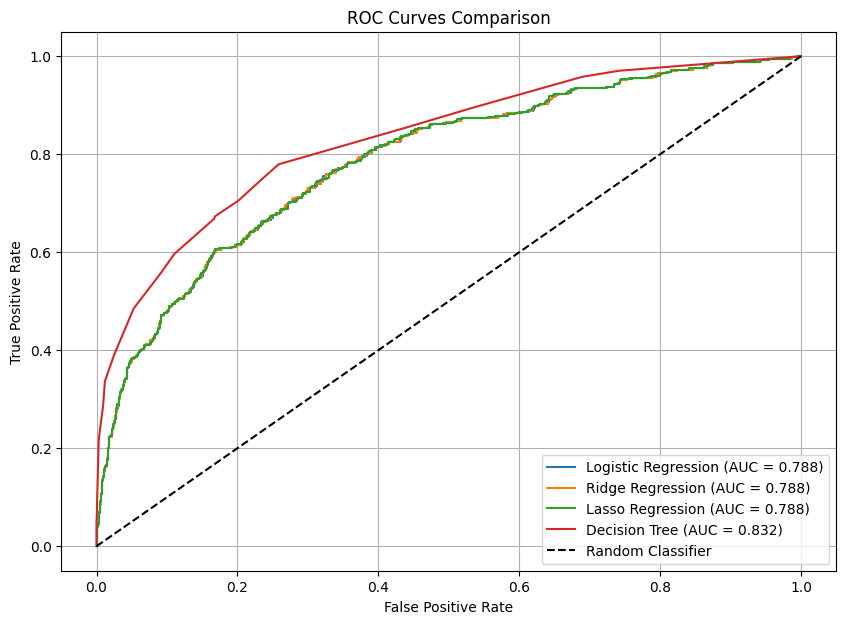

In [65]:
# Visualization: ROC Curves

plt.figure(figsize=(10, 7))

# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})')

# Ridge ROC
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_prob_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f'Ridge Regression (AUC = {roc_auc_score(y_test, y_prob_ridge):.3f})')

# Lasso ROC
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso Regression (AUC = {roc_auc_score(y_test, y_prob_lasso):.3f})')

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

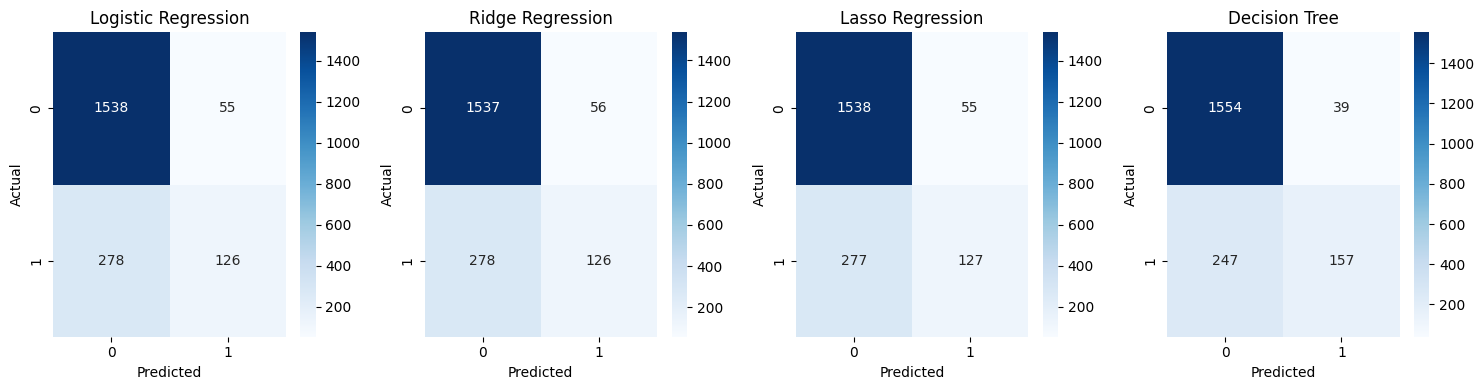

In [73]:
# Confusion Matrix Visualization

fig, axes = plt.subplots(1, 4, figsize=(15,4))

models_preds = [
    ('Logistic Regression', y_pred_log),
    ('Ridge Regression', y_pred_ridge),
    ('Lasso Regression', y_pred_lasso),
    ('Decision Tree', y_pred_dt)
]

for idx, (name, y_pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

##  Interpretability & Insights


 
FEATURE IMPORTANCE ANALYSIS
 


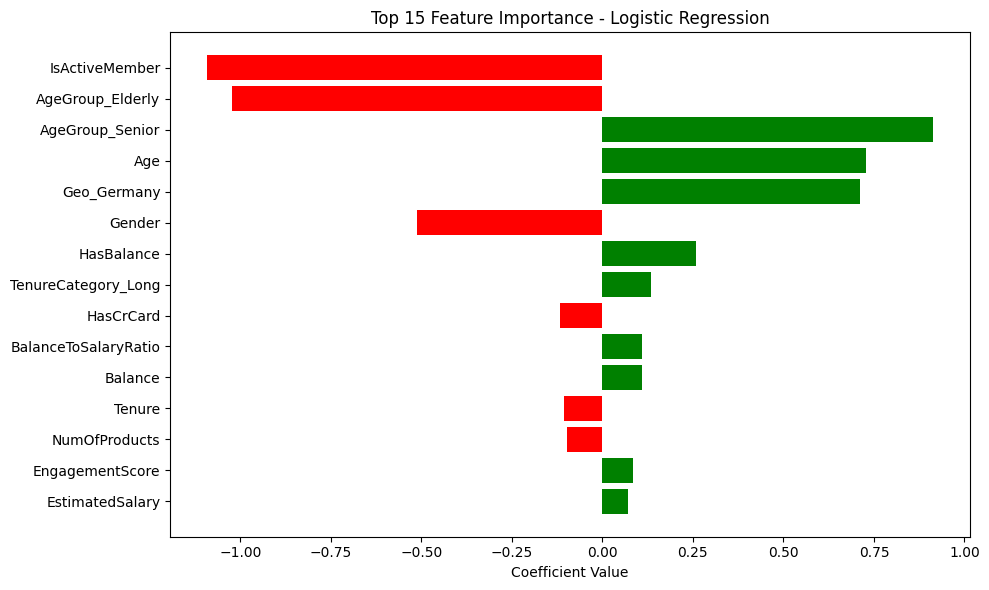

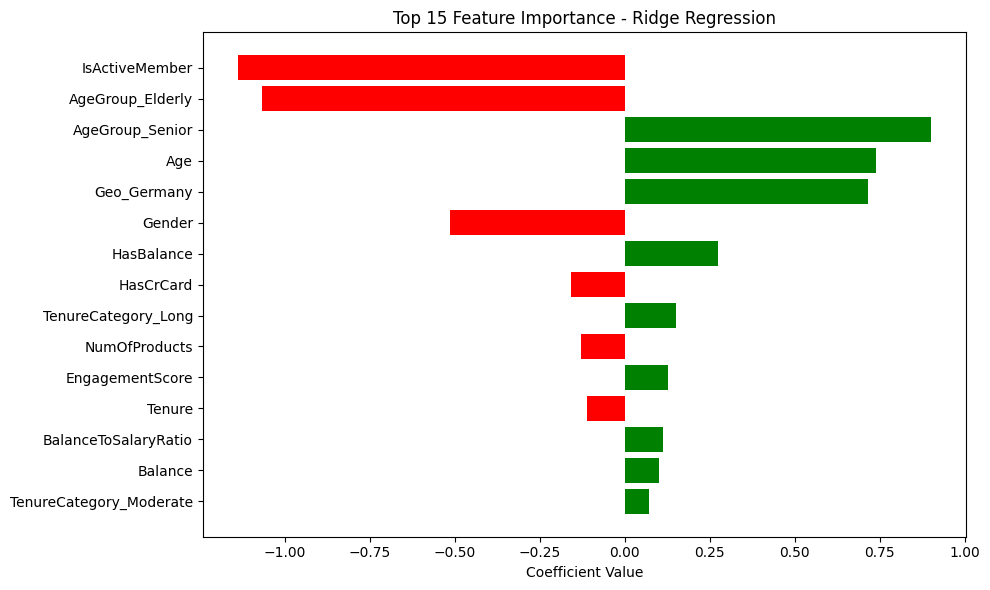

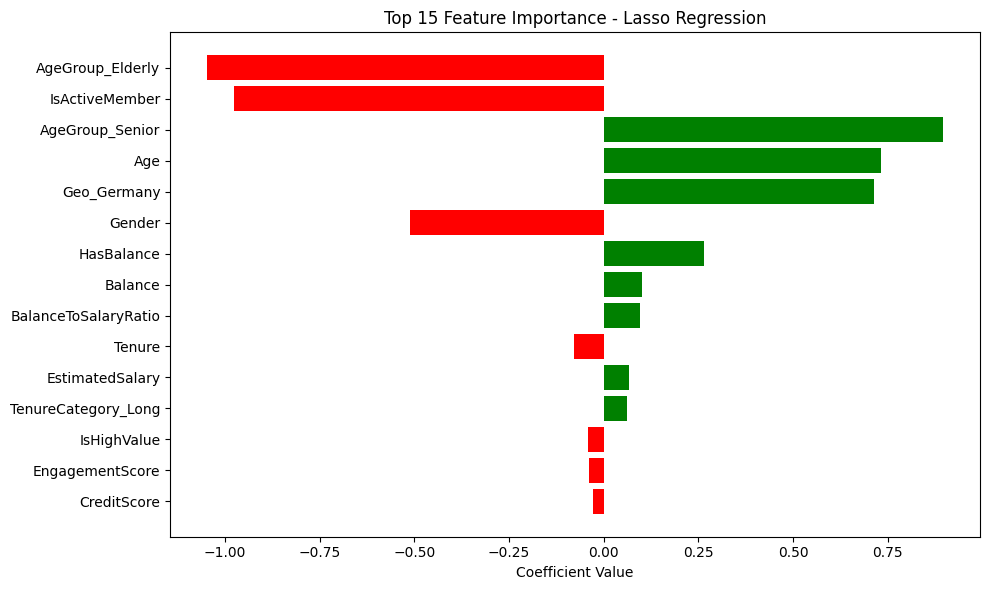

In [102]:
# Feature Importance

def plot_feature_importance(model, feature_names, model_name, top_n=15):
    importance = model.coef_[0] if hasattr(model, 'coef_') else model.feature_importances_

    df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).assign(abs_imp=lambda x: x.Importance.abs()) \
      .sort_values('abs_imp', ascending=False) \
      .head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(df.Feature, df.Importance,
             color=['red' if v < 0 else 'green' for v in df.Importance])
    plt.title(f'Top {top_n} Feature Importance - {model_name}')
    plt.xlabel('Coefficient Value')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return df[['Feature', 'Importance']]

print("\n" + " ")
print("FEATURE IMPORTANCE ANALYSIS")
print(" ")

log_imp   = plot_feature_importance(log_reg, X.columns, "Logistic Regression")
ridge_imp = plot_feature_importance(ridge_reg, X.columns, "Ridge Regression")
lasso_imp = plot_feature_importance(lasso_reg, X.columns, "Lasso Regression")


Generating SHAP values...


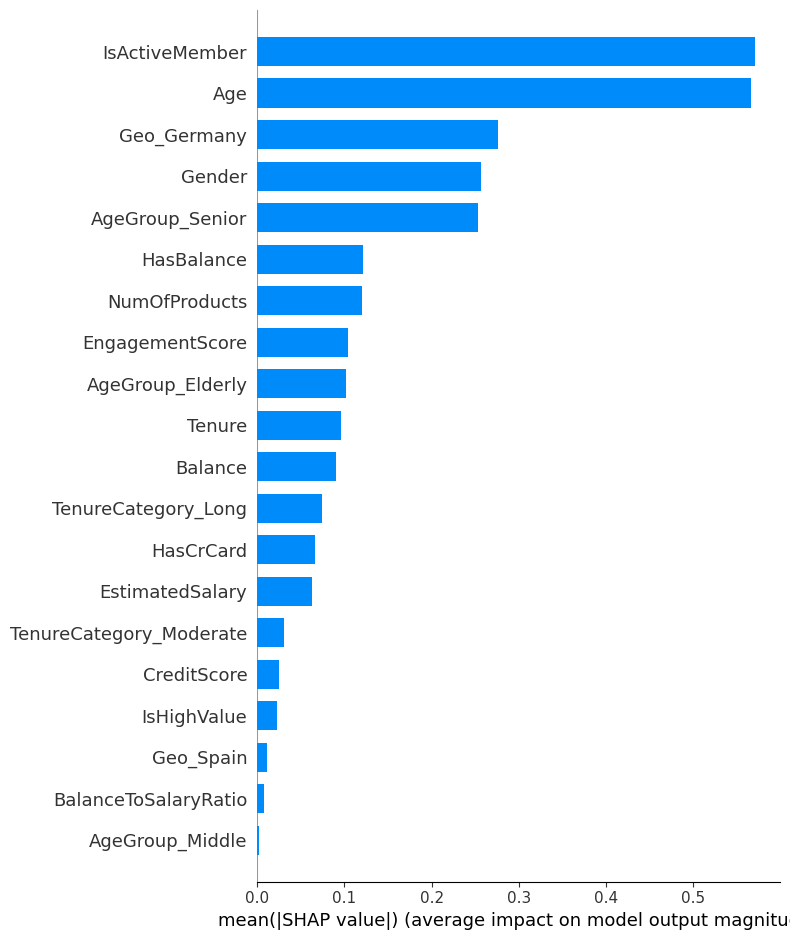

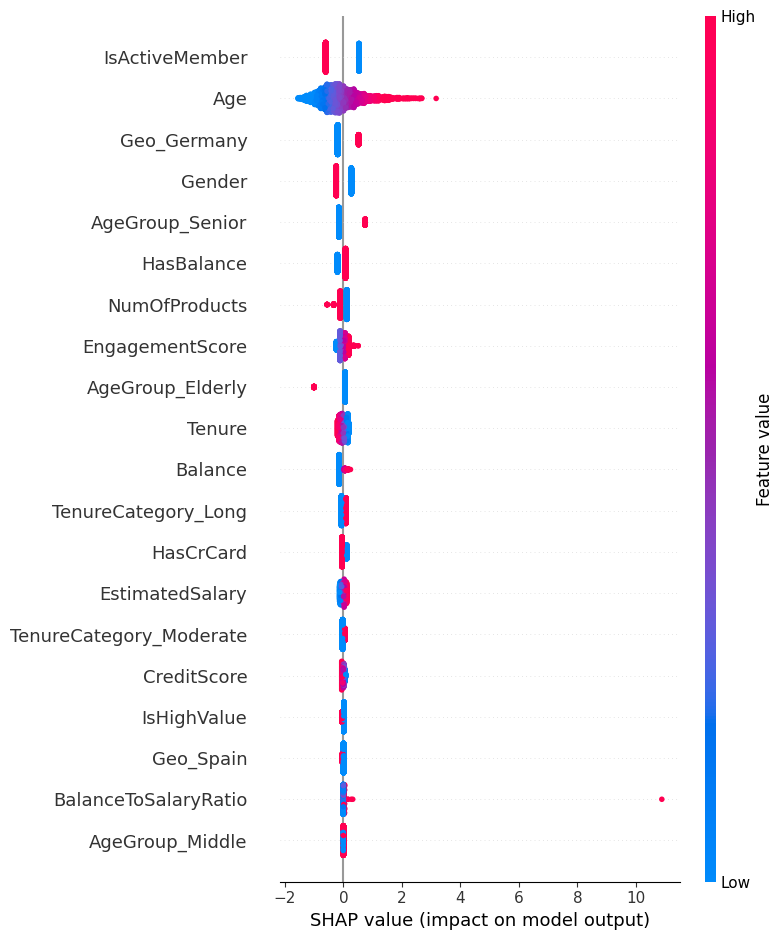

In [101]:
print("Generating SHAP values...")

# Convert to clean NumPy arrays
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

# Use universal SHAP explainer
explainer = shap.Explainer(ridge_reg, X_train_np)
shap_values = explainer(X_test_np)

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_np,
    feature_names=X.columns,
    plot_type="bar"
)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_np,
    feature_names=X.columns
)


Generating LIME Explanation for a sample prediction...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


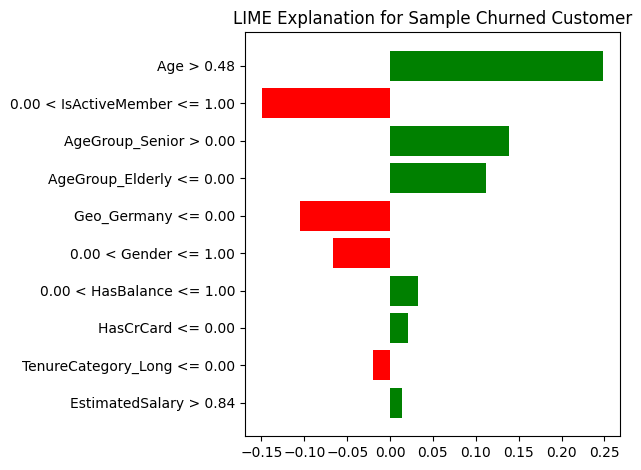

In [86]:
# LIME Explanation

print("Generating LIME Explanation for a sample prediction...")

sample_idx = y_test[y_test == 1].index[0]
sample = X_test.loc[sample_idx].values

lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=['Stay', 'Churn'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    sample,
    ridge_reg.predict_proba,
    num_features=10
)

lime_exp.as_pyplot_figure()
plt.title("LIME Explanation for Sample Churned Customer")
plt.tight_layout()
plt.show()

In [90]:
# Key Insights Summary

print("KEY INSIGHTS FROM MODEL INTERPRETABILITY:")

print("\nTop Factors Contributing to Churn:")
print(log_imp.head(10).to_string(index=False))

print("\nBusiness Insights:")
print("1. Age: Older customers are more likely to churn")
print("2. Geography: Customers from certain regions have higher churn rates")
print("3. Active Membership: Inactive members are significantly more likely to leave")
print("4. Number of Products: Customers with 3+ products show unusual patterns")
print("5. Balance: Customers with zero balance or very high balance tend to churn")
print("6. Engagement Score: Lower engagement directly correlates with churn")

KEY INSIGHTS FROM MODEL INTERPRETABILITY:

Top Factors Contributing to Churn:
             Feature  Importance
      IsActiveMember   -1.093321
    AgeGroup_Elderly   -1.023156
     AgeGroup_Senior    0.914174
                 Age    0.728238
         Geo_Germany    0.711755
              Gender   -0.512541
          HasBalance    0.257225
 TenureCategory_Long    0.133426
           HasCrCard   -0.118361
BalanceToSalaryRatio    0.109863

Business Insights:
1. Age: Older customers are more likely to churn
2. Geography: Customers from certain regions have higher churn rates
3. Active Membership: Inactive members are significantly more likely to leave
4. Number of Products: Customers with 3+ products show unusual patterns
5. Balance: Customers with zero balance or very high balance tend to churn
6. Engagement Score: Lower engagement directly correlates with churn


In [99]:
# Model Performance Summary

print("\n" + "="*70)
print("FINAL PROJECT REPORT: BANK CUSTOMER CHURN PREDICTION")
print("="*70)

# Dataset Info
print("\nDATASET INFORMATION")
print(f"   Total Records: {df_clean.shape[0]}")
print(f"   Total Features Used: {X.shape[1]}")
print(f"   Churn Rate: {(y.mean() * 100):.2f}%")

# Data Cleaning
print("\nDATA CLEANING")
print("   Missing Values: Checked (None Found)")
print(f"   Duplicate Records: {df_clean.duplicated().sum()}")
print("   Outliers: Identified (Selective handling applied)")

# Feature Engineering
print("\nFEATURE ENGINEERING")
print("   Feature Scaling: Applied")
print("   Encoding: Applied to categorical variables")
print("   Final Feature Set Ready for Modeling")

# Models
print("\nMODELS TRAINED")
print("   1. Logistic Regression")
print("   2. Ridge Regression (L2)")
print("   3. Lasso Regression (L1)")
print("   4. Decision Tree")

# Best Model
print("\nBEST MODEL PERFORMANCE")
best_model_idx = results_df['ROC_AUC'].idxmax()
best_model = results_df.loc[best_model_idx]

print(f"   Model Name: {best_model['Model']}")
print(f"   ROC-AUC: {best_model['ROC_AUC']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1-Score: {best_model['F1']:.4f}")

# Feature Importance
print("\nTOP 5 IMPORTANT FEATURES (Logistic/Ridge Model)")
print(log_imp.head(5).to_string(index=False))

# Business Insights
print("\nBUSINESS RECOMMENDATIONS")
print("   1. Identify high-risk customers early using churn probability scores")
print("   2. Improve engagement strategies for inactive customers")
print("   3. Monitor customers with unusual balance or salary patterns")
print("   4. Use predictive scores to trigger retention campaigns")
print("   5. Focus on long-term customer value rather than short-term profit")

print("\nPROJECT COMPLETED SUCCESSFULLY!!!")

# Save Results

results_df.to_csv("model_comparison.csv", index=False)
log_imp.to_csv("feature_importance.csv", index=False)

print("\nFILES SAVED:")
print("   - model_comparison.csv")
print("   - feature_importance.csv")


FINAL PROJECT REPORT: BANK CUSTOMER CHURN PREDICTION

DATASET INFORMATION
   Total Records: 9985
   Total Features Used: 20
   Churn Rate: 20.25%

DATA CLEANING
   Missing Values: Checked (None Found)
   Duplicate Records: 0
   Outliers: Identified (Selective handling applied)

FEATURE ENGINEERING
   Feature Scaling: Applied
   Encoding: Applied to categorical variables
   Final Feature Set Ready for Modeling

MODELS TRAINED
   1. Logistic Regression
   2. Ridge Regression (L2)
   3. Lasso Regression (L1)
   4. Decision Tree

BEST MODEL PERFORMANCE
   Model Name: Decision Tree
   ROC-AUC: 0.8321
   Accuracy: 0.8538
   F1-Score: 0.5731

TOP 5 IMPORTANT FEATURES (Logistic/Ridge Model)
         Feature  Importance
  IsActiveMember   -1.093321
AgeGroup_Elderly   -1.023156
 AgeGroup_Senior    0.914174
             Age    0.728238
     Geo_Germany    0.711755

BUSINESS RECOMMENDATIONS
   1. Identify high-risk customers early using churn probability scores
   2. Improve engagement strategies